In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

%matplotlib inline
sns.set_style("whitegrid")



In [38]:
df=pd.read_csv("online_retail.csv")

In [39]:
df.shape

(541909, 8)

In [40]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [41]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [42]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 69.3 MB


In [43]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [44]:
df=df.dropna(subset=['CustomerID'])

In [45]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [46]:
df.dtypes

InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object

In [47]:
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])

In [48]:
df.dtypes

InvoiceNo                 str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

In [49]:
df['InvoiceNo'].astype(str).str.startswith('C').value_counts()

InvoiceNo
False    397924
True       8905
Name: count, dtype: int64

In [50]:
df=df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [51]:
df.shape

(397924, 8)

In [52]:
df['TotalAmount']=df['Quantity']*df['UnitPrice']

In [53]:
df[['Quantity','UnitPrice','TotalAmount']].head()

,Quantity,UnitPrice,TotalAmount
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [54]:
analysis_date=df['InvoiceDate'].max()+pd.Timedelta(days=1)

print("Analysis Date:", analysis_date)

rfm=df.groupby('CustomerID').agg({
    'InvoiceDate':lambda x:(analysis_date - x.max()).days,
    'InvoiceNo':'unique',
    'TotalAmount':'sum'
})

rfm.columns=['Recency','Frequrncy','Monetary']
rfm.head()

rfm.shape

rfm.describe()

rfm.isnull().sum()

print("Minimum Monetary Value:",rfm['Monetary'].min())
print("Maximum Monetary Value:",rfm['Monetary'].max())

Analysis Date: 2011-12-10 12:50:00
Minimum Monetary Value: 0.0
Maximum Monetary Value: 280206.02


## RFM Analysis

RFM analysis was used to understand customer purchasing behaviour.

- **Recency:** Number of days since the customer's most recent purchase.
- **Frequency:** Number of unique invoices/orders made by the customer.
- **Monetary:** Total amount spent by the customer.

These three behavioural features will be used for customer segmentation using K-Means clustering.

In [55]:
print(rfm.columns)

Index(['Recency', 'Frequrncy', 'Monetary'], dtype='str')


In [56]:
analysis_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (analysis_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalAmount', 'sum')
)

rfm.head()

print(rfm.columns)

rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]

rfm_features.head()


rfm_features.describe()



Index(['Recency', 'Frequency', 'Monetary'], dtype='str')


,Recency,Frequency,Monetary
count,4339.000000,4339.000000,4339.000000
mean,92.518322,4.271952,2053.793018
std,100.009747,7.705493,8988.248381
min,1.000000,1.000000,0.000000
25%,18.000000,1.000000,307.245000
50%,51.000000,2.000000,674.450000
75%,142.000000,5.000000,1661.640000
max,374.000000,210.000000,280206.020000


In [57]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_features)

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=['Recency', 'Frequency', 'Monetary'],
    index=rfm.index
)

rfm_scaled.head()

rfm_scaled.describe()

,Recency,Frequency,Monetary
count,4.339000e+03,4.339000e+03,4.339000e+03
mean,7.532834e-17,1.965087e-17,-4.093931e-17
std,1.000115e+00,1.000115e+00,1.000115e+00
min,-9.151995e-01,-4.246749e-01,-2.285239e-01
25%,-7.451965e-01,-4.246749e-01,-1.943370e-01
50%,-4.151906e-01,-2.948824e-01,-1.534784e-01
75%,4.948256e-01,9.449517e-02,-4.363455e-02
max,2.814867e+00,2.670196e+01,3.094978e+01


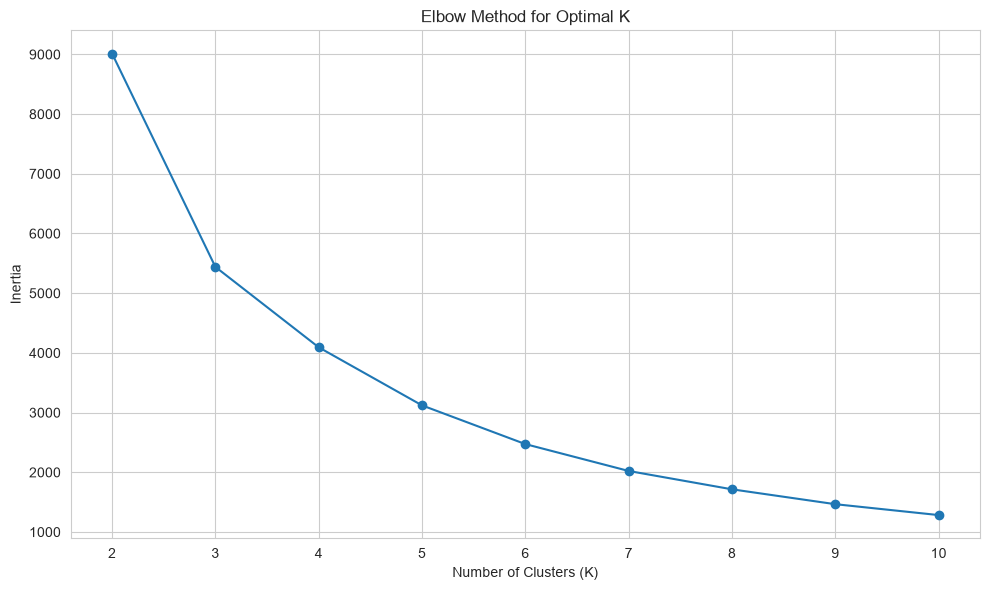

In [58]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), inertia, marker='o')

plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(range(2, 11))

plt.tight_layout()
plt.show()

In [59]:
optimal_k=4
kmeans=KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)
rfm['Cluster']=kmeans.fit_predict(rfm_scaled)
rfm.head()

    

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,0
12347.0,2,7,4310.00,3
12348.0,75,4,1797.24,3
12349.0,19,1,1757.55,3
12350.0,310,1,334.40,1


In [60]:
cluster_counts=rfm['Cluster'].value_counts().sort_index()
print(cluster_counts)

Cluster
0     211
1    1062
2      13
3    3053
Name: count, dtype: int64


In [61]:
cluster_profile = rfm.groupby('Cluster')[
    ['Recency', 'Frequency', 'Monetary']
].mean().round(2)

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,15.67,22.05,12453.23
1,248.56,1.55,478.11
2,7.38,82.69,127338.31
3,43.91,3.66,1349.70


In [62]:
cluster_counts = rfm['Cluster'].value_counts().sort_index()

print(cluster_counts)


Cluster
0     211
1    1062
2      13
3    3053
Name: count, dtype: int64


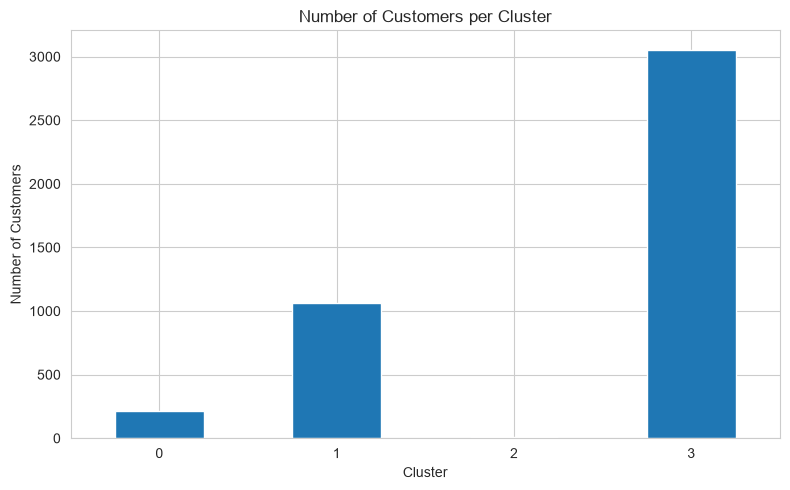

In [63]:
plt.figure(figsize=(8, 5))

cluster_counts.plot(kind='bar')

plt.title('Number of Customers per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

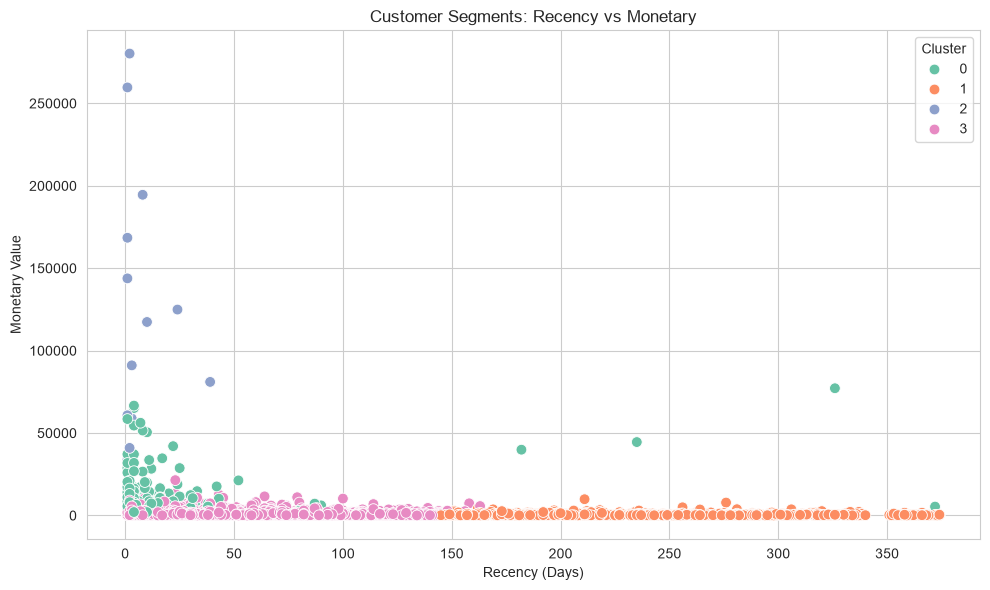

In [64]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Cluster',
    palette='Set2',
    s=60
)

plt.title('Customer Segments: Recency vs Monetary')
plt.xlabel('Recency (Days)')
plt.ylabel('Monetary Value')
plt.tight_layout()
plt.show()

In [65]:
average_purchase_value = df['TotalAmount'].mean()

print("Average Purchase Value:", round(average_purchase_value, 2))

Average Purchase Value: 22.39


In [66]:
average_purchase_frequency = rfm['Frequency'].mean()

print("Average Purchase Frequency:", round(average_purchase_frequency, 2))

Average Purchase Frequency: 4.27


In [67]:
average_customer_lifetime_value = rfm['Monetary'].mean()

print(
    "Average Customer Lifetime Value (Observed Spend):",
    round(average_customer_lifetime_value, 2)
)

Average Customer Lifetime Value (Observed Spend): 2053.79


In [68]:
print("Average Purchase Value:", round(average_purchase_value, 2))
print("Average Purchase Frequency:", round(average_purchase_frequency, 2))
print("Average Customer Lifetime Value:", round(average_customer_lifetime_value, 2))

Average Purchase Value: 22.39
Average Purchase Frequency: 4.27
Average Customer Lifetime Value: 2053.79


## Descriptive Statistics

The descriptive analysis was performed to understand overall customer purchasing behaviour.

- **Average Purchase Value:** Represents the average value of individual transactions.
- **Average Purchase Frequency:** Represents the average number of unique invoices/orders per customer.
- **Customer Lifetime Value:** In this analysis, total observed customer spending is used as a simple proxy for customer lifetime value.

These measures provide a baseline understanding of customer purchasing behaviour before analysing the individual customer segments.

In [69]:
cluster_profile = rfm.groupby('Cluster')[
    ['Recency', 'Frequency', 'Monetary']
].mean().round(2)

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,15.67,22.05,12453.23
1,248.56,1.55,478.11
2,7.38,82.69,127338.31
3,43.91,3.66,1349.70


In [70]:
cluster_counts = rfm['Cluster'].value_counts().sort_index()

cluster_counts

Cluster
0     211
1    1062
2      13
3    3053
Name: count, dtype: int64

## Cluster Profiling and Customer Segments

The K-Means clustering analysis identified four distinct customer segments based on Recency, Frequency, and Monetary value.

### Cluster 0 – Recent, High-Value Customers
These customers have purchased recently, show relatively high purchase frequency, and have high total spending. They can be engaged through loyalty programs, personalized recommendations, and exclusive offers.

### Cluster 1 – Inactive, Low-Engagement Customers
These customers have a high recency value, meaning they have not purchased for a long period. They also have low purchase frequency and low spending. Reactivation campaigns, personalized discounts, and reminder emails can be used to encourage them to return.

### Cluster 2 – Very Frequent, High-Value Customers
These customers have the lowest recency value, very high purchase frequency, and high total spending. Loyalty rewards, premium services, exclusive products, and retention campaigns can be used to maintain their engagement.

### Cluster 3 – Occasional, Lower-Value Customers
These customers purchase less frequently and have relatively low spending. Product recommendations, bundle offers, and incentives for repeat purchases can help increase their purchase frequency.

## Marketing Insights and Actions

| Cluster | Customer Segment | Suggested Marketing Action |
|---|---|---|
| 0 | Recent, High-Value | Loyalty rewards, personalized offers, and product recommendations |
| 1 | Inactive, Low-Engagement | Win-back campaigns, reminders, and targeted discounts |
| 2 | Very Frequent, High-Value | Premium offers, loyalty benefits, exclusive products, and retention campaigns |
| 3 | Occasional, Lower-Value | Product recommendations, bundle offers, and repeat-purchase incentives |

In [71]:
cluster_counts = rfm['Cluster'].value_counts().sort_index()

cluster_percentage = (cluster_counts / len(rfm) * 100).round(2)

cluster_summary = pd.DataFrame({
    'Customer Count': cluster_counts,
    'Percentage': cluster_percentage
})

cluster_summary

,Customer Count,Percentage
Cluster,,
0,211,4.86
1,1062,24.48
2,13,0.30
3,3053,70.36


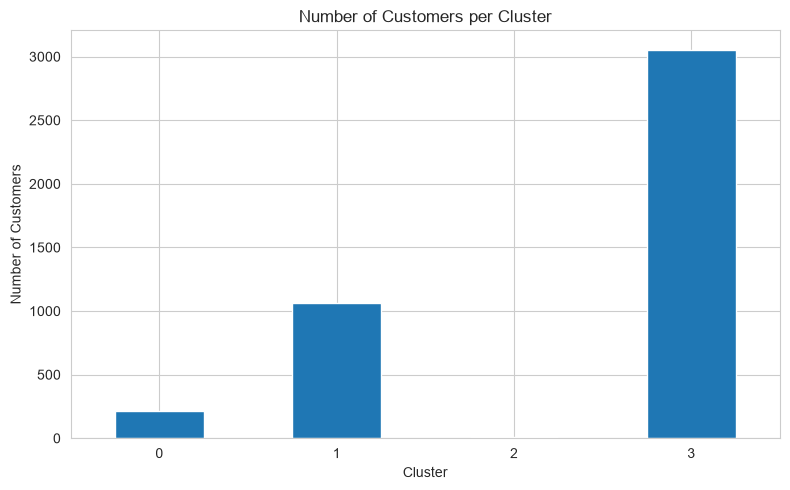

In [72]:
plt.figure(figsize=(8, 5))

cluster_counts.plot(kind='bar')

plt.title('Number of Customers per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## Key Insights

1. **High-value customers:** Clusters 0 and 2 show high monetary values. Cluster 2 has the highest purchase frequency and very recent purchasing activity, while Cluster 0 also shows strong customer engagement.

2. **Inactive customers:** Cluster 1 has a very high recency value and low frequency and monetary value, indicating a group with limited recent engagement. This segment can be targeted with reactivation campaigns.

3. **Occasional customers:** Cluster 3 has lower frequency and monetary value compared with Clusters 0 and 2. Encouraging repeat purchases can help increase customer engagement.

4. **Customer behaviour differs significantly:** The RFM analysis demonstrates that customers vary substantially in recency, purchase frequency, and spending. Therefore, a single marketing strategy may not be suitable for all customers.

## Business Recommendations

1. **Strengthen customer loyalty:** Provide loyalty rewards, personalized recommendations, and exclusive offers to high-frequency and high-value customers, particularly Clusters 0 and 2.

2. **Reactivate inactive customers:** Target Cluster 1 with personalized emails, limited-time discounts, and win-back campaigns to encourage repeat purchases.

3. **Increase repeat purchases:** Use product recommendations, bundle offers, and follow-up promotions for Cluster 3 to increase purchase frequency.

4. **Use personalized marketing:** Develop different campaigns for each customer segment instead of applying the same marketing strategy to the entire customer base.

5. **Monitor customer segments regularly:** Recalculate RFM metrics periodically because customer behaviour can change over time.

## Conclusion

Customer segmentation was performed using RFM analysis and K-Means clustering on the Online Retail dataset.

The analysis used three behavioural features: Recency, Frequency, and Monetary value. The features were standardized using StandardScaler before applying K-Means clustering. The Elbow Method was used to determine the number of clusters.

The resulting customer segments showed clear differences in purchasing behaviour, ranging from highly engaged and high-value customers to inactive and lower-value customers.

These segments can help an e-commerce business develop targeted marketing strategies, improve customer retention, encourage repeat purchases, and focus resources on different customer groups according to their purchasing behaviour.